## Simulator demo for Gemini logical
Gemini logical is a specific set of dialects and compilers in bloqade. This demo is hosted in the `bloqade-lanes` repo, which is where the move synthesis compiler lives.

In [1]:
# Builtins
import math
from collections import Counter
import numpy as np

# Types
from typing import Any
from bloqade.decoders.dialects.annotate.types import Detector, Observable
from kirin.dialects import ilist
from kirin.ir.method import Method
from bloqade import types

# Functions and methods
from bloqade.decoders import BpLsdDecoder
from bloqade.lanes.device import GeminiLogicalSimulator

# Dialect groups
from bloqade.gemini import logical
from bloqade import qubit, squin

In [2]:

import matplotlib.pyplot as plt

def render_steane_code_qubit(ax:plt.Axes | None = None,center:tuple[float,float]=(0,0))->plt.Axes:
    if ax is None:
        fig,ax = plt.subplots()
        ax.set_aspect("equal")
        ax.set_xlim([-2+center[0],2+center[0]])
        ax.set_ylim([-2+center[1],2+center[1]])
        ax.axis("off")
    RED = "#EF2F55"
    PURPLE = "#670EFF"
    GREEN = "#57BC13"

    pos_center = np.zeros([2,7])
    pos_center[:,1::] = np.array([np.cos(np.linspace(0,2*np.pi,7)[0:6])*1.5,1.5*np.sin(np.linspace(0,2*np.pi,7)[0:6])])
    pos_center += np.array(center).reshape(2,1)

    ax.scatter(pos_center[0],pos_center[1],color="w",s=800,zorder=100,edgecolors="k")
    indexing = [2,0,3,6,4,5,1]
    for xi, yi, label in zip(pos_center[0],pos_center[1],indexing):
        ax.text(xi,yi,str(label),ha="center",va="center",zorder=200)

    ax.fill([pos_center[0,x] for x in [0,2,3,4]],[pos_center[1,x] for x in [0,2,3,4]],color=RED)
    ax.fill([pos_center[0,x] for x in [0,4,5,6]],[pos_center[1,x] for x in [0,4,5,6]],color=GREEN)
    ax.fill([pos_center[0,x] for x in [0,6,1,2]],[pos_center[1,x] for x in [0,6,1,2]],color=PURPLE)
    logical_label = [indexing.index(5), indexing.index(1), indexing.index(0)]
    ax.plot(pos_center[0,logical_label],pos_center[1,logical_label],color="k",ls="-",linewidth=5,zorder=50)
    
    return ax

# A minimal kernel that prepares a single qubit in an arbitrary state,
# so that it can be shown by the tsim renderer.
@logical.kernel(aggressive_unroll=True, verify=True)
def main():
    reg = qubit.qalloc(1)
    squin.u3(0.1,0.2,0.3,reg[0])
    return logical.terminal_measure(reg)
task = GeminiLogicalSimulator().task(main)

### Some prototype stdutils functions: detectors and observables
We break abstraction a bit between physical and logical qubits. Each logical measurement is a batch of 7 physical measurements as indexed by the following diagram.

In order to correct the errors from a Steane code, we need to inform the decoder and detector error model of the decoding steps. This can be done by defining the **detectors** and the **observables**.

For the Steane code, the detectors are four-qubit parity patches corresponding to the three plaquettes of the code; in the following render the default detectors are red/green/purple patches.

For the Steane code, the obsevables are three-qubit parity lines corresponding to edges of the code; in the following render is default observable are the black line.

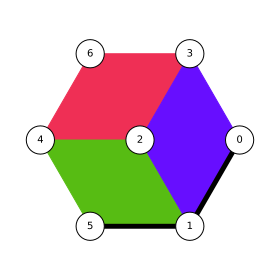

In [3]:
render_steane_code_qubit()
task.tsim_circuit.diagram(width=400)

Lets define some default functions which use the `squin.set_detector` and `squin.set_observable` functions, which annotate the program for later analysis to generate the detector error model.

In [4]:
@logical.kernel(aggressive_unroll=True, verify=False)
def set_detector(meas: ilist.IList[types.MeasurementResult, Any]) -> list[Detector]:
    """
    Define default detectors for the Steane code.
    """
    return [
        squin.set_detector([meas[0], meas[1], meas[2], meas[3]], coordinates=[0, 0]), # Purple patch
        squin.set_detector([meas[1], meas[2], meas[4], meas[5]], coordinates=[0, 1]), # Green patch
        squin.set_detector([meas[2], meas[3], meas[4], meas[6]], coordinates=[0, 2]), # Red patch
    ]

@logical.kernel(aggressive_unroll=True, verify=False)
def set_observable(
    meas: ilist.IList[types.MeasurementResult, Any], index: int
) -> Observable:
    """
    Define default observables for the Steane code.
    """
    return squin.set_observable([meas[0], meas[1], meas[5]], index) # Black line

@logical.kernel(aggressive_unroll=True, verify=False)
def default_observe(
    measurements: ilist.IList[ilist.IList[types.MeasurementResult, Any], Any],
) -> tuple[list[Detector], list[Observable]]:
    """
    A default observe utility function that sets a default set of detectors and observables
    based on the underlying physical measurement results.
    """
    detectors = []
    observables = []
    for i in range(len(measurements)):
        detectors = detectors + set_detector(measurements[i])
        observables = observables + [set_observable(measurements[i], i)]
    return detectors, observables

For the purposes of our demonstration, lets prepare a simple GHZ state. Note that the decorator is `@logical.kernel` instead of `@squin.kernel`.

In [5]:
@logical.kernel(aggressive_unroll=True, verify=True)
def main():
    reg = qubit.qalloc(3)
    squin.h(reg[0])
    squin.cx(reg[0], reg[1])

    measurements = logical.terminal_measure(reg)
    default_observe(measurements) # Annotate detectors and observables based on the measurements
    return measurements # Return the physical measurements

task = GeminiLogicalSimulator().task(main)

The `task` has several attributes. The key attributes are:
| Attribute         | Description                          |
|-------------------|--------------------------------------|
| `task.run`        | Run the task, sampling bitstrings from the noisy distribution |
| `task.noiseless_tsim_circuit`             | The underlying physical circuit without noise        |
| `task.tsim_circuit`             | The underlying physical circuit including noise             |
| `task.detector_error_model`           | The DEM associated with the noisy circuit       |
| `task.visualize`     | Render an interactive atom move. Does not work in jupyter notebooks =(     |

## Rendering of the noiseless circuit:

In [6]:
task.noiseless_tsim_circuit.diagram(height=task.noiseless_tsim_circuit.num_qubits*25)

## Rendering of the noisy circuit:
Includes 1 and 2 qubit gate error, spectator errors, and move errors. It does not include state preparation errors.

In [7]:
task.tsim_circuit.diagram(height=task.tsim_circuit.num_qubits*25)

## Running the task
the `task.run` attribute compiles the task to tsim and then samples from it. Note that the majority of the time is spent compiling the task; the sampler is very fast.

In [8]:
result = task.run(1, with_noise=True)
result_wo_noise = task.run(1, with_noise=False)

In [9]:
# After recompilation, the task runs very quickly.
result = task.run(10000, with_noise=True)
result_wo_noise = task.run(10000, with_noise=False)

The `result` object has several meaningful attributes that are useful for analysis:
| Attribute         | Description                          |
|-------------------|--------------------------------------|
| `result.return_values`        | The values returned from the kernel |
| `result.detectors` | The parity values of the annotated detectors |
| `result.observables` | The parity values of the annotated observables |
| `result.physical` | The physical qubit measurements |

For each value, the zeroth dimension is the shot index.
- `detectors` are a flattened list of `[ [detectors of qubit 0 ], [detectors of qubit 1] [ ... ] ]`
- `observables` are a list of `[ obsevable of qubit 0, observable of qubit 1, ... ]`
- `physical` is a nested list of `[[7 physical measurements of qubit 0], [7 physical measurements of qubit 1], ...]`

Indexing is in the same ordering of however the qubits were measured in the `logical.terminal_measure` statement.

In [10]:
return_values = result.return_values
detectors = np.asarray(result.detectors)
observables = np.asarray(result.observables)
physical = np.asarray(return_values) #np.asarray(result.physical) # Pending https://github.com/QuEraComputing/bloqade-lanes/issues/193
observables_without_noise = np.asarray(result_wo_noise.observables)

print(detectors.shape)
print(observables.shape)
print(physical.shape)

(10000, 9)
(10000, 3)
(10000, 3, 7)


## Decoding and post-selection
Decoders can be inhereted from elsewhere but follow a common pattern. Given the detector error model, flips to the logical qubits can be decoded based on the detector triggers. Because the code is linear, the corrected code is simply the XOR of the flips and the observables.

Alternatively, one may postselect on having no errors, or all detectors being zero.

In [11]:
# Correct
flips = BpLsdDecoder(task.detector_error_model).decode(detectors)
observables_corrected = observables ^ flips
print("Average bits flipped:", np.average(flips))

# Postselect
post_selection = np.all(detectors == 0, axis=1)
observables_postselected = observables[post_selection, :]
print("Postselection rate:  ", len(observables_postselected) / len(observables))

Average bits flipped: 0.024566666666666667
Postselection rate:   0.892


## Analysis 1: parity
For the GHZ state, we have the convenience of the final state being uniformly sampled from 00 or 11, with 01 or 10 indicating an error outside of the distribution. Thus, computing the parity of the observables can serve as a proxy of the fidelity of the distribution: parity 0 means no error, parity 1 means error, and the average parity is the error rate. Postselection and correction decreases the parity, meaning the final error is better!

In [12]:
print("Average parity (before correction):", np.average(observables[:,0] ^ observables[:,1]))
print("Average parity (after correction):", np.average(observables_corrected[:,0] ^ observables_corrected[:,1]))
print("Average parity (after postselection):", np.average(observables_postselected[:,0] ^ observables_postselected[:,1]))

Average parity (before correction): 0.0275
Average parity (after correction): 0.0044
Average parity (after postselection): 0.0


### Some helper functions and standard utilities to analyze statistical divergence

In [13]:
# helper functions to analyze statistical distribution of logical measurements
def get_hist(obs_array: np.ndarray):
    return Counter(map(lambda x: tuple(map(int, x)), obs_array[:]))

def kl_divergence(p_hist: Counter, q_hist: Counter) -> float:
    """Compute the KL divergence D_KL(P || Q) between two histograms."""
    total_p = sum(p_hist.values())
    total_q = sum(q_hist.values())
    if total_p == 0 or total_q == 0:
        return float("inf")  # Infinite divergence if one distribution is empty
    divergence = 0.0
    for key in p_hist:
        p_prob = p_hist[key] / total_p
        q_prob = q_hist.get(key, 0) / total_q
        if q_prob > 0:
            divergence += p_prob * math.log(p_prob / q_prob)
        else:
            divergence += p_prob * math.log(p_prob / (1e-10))  # Avoid log(0)
    return divergence


The Kullback-Leibler divergence $D_{KL}(P||Q)$ measures the dissimilarity between two probability distributions. When the KL divergence is zero, there is no loss when the noisy distribution (Q) is used to represent the perfect distribution (P). Similar to the parity measurement above, we find that the divergence is lower for corrected and postselected distributions. Note that the distribution is approximated from finite sampling (a simple frequentist bootstrap) so the KL divergence is an upper bound on the true distribution.

In [14]:
observables_hist = get_hist(observables)
observables_decoded_hist = get_hist(observables_corrected)
observables_postselected_hist = get_hist(observables_postselected)
observables_wo_noise_hist = get_hist(observables_without_noise)

# compute and print the KL divergence between the histograms
print("KL divergence between noiseless and raw observables:",kl_divergence(observables_wo_noise_hist, observables_hist))
print("KL divergence between noiseless and decoded observables:",kl_divergence(observables_wo_noise_hist, observables_decoded_hist))
print("KL divergence between noiseless and post-selected observables:",kl_divergence(observables_wo_noise_hist, observables_postselected_hist))


KL divergence between noiseless and raw observables: 0.03565228681922565
KL divergence between noiseless and decoded observables: 0.004566115741566371
KL divergence between noiseless and post-selected observables: 1.2921878847972634e-05


### Dos and do nots for kernels
A valid kernel for Gemini must:
1. Have less than 10 qubits
2. Only have a single non-Clifford gate per qubit, acting as a single-qubit gate as the first gate on each qubit
3. Measurement is in Z basis only.

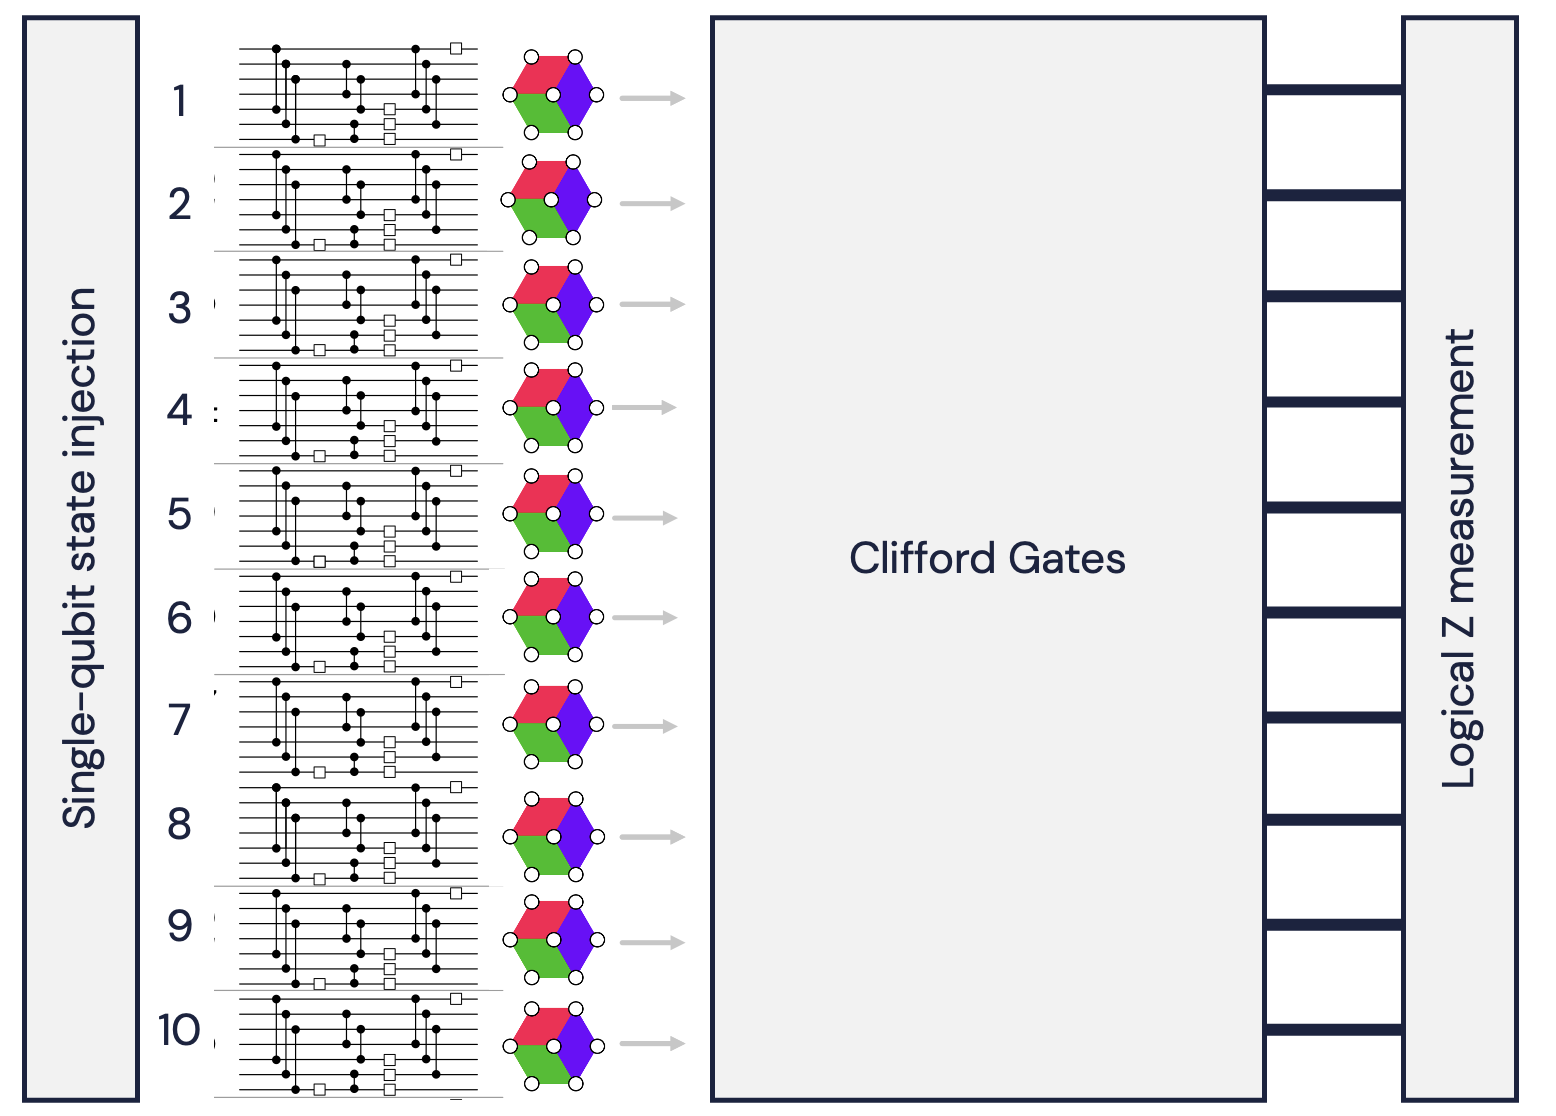

Too many qubits

In [15]:
try:
    @logical.kernel(aggressive_unroll=True, verify=True)
    def main()->tuple[list[Detector], list[Observable]]:
        reg = qubit.qalloc(12)
        squin.h(reg[0])
        squin.cx(reg[0], reg[1])

        return default_observe(reg)

    task = GeminiLogicalSimulator().task(main)
except BaseException as e:
    print("Error during kernel definition or task creation:", e)

Error during kernel definition or task creation: Number of qubits in circuit (12) exceeds maximum supported by logical architecture (10)


Repeated non-Clifford rotations

In [16]:
try:
    @logical.kernel(aggressive_unroll=True, verify=True)
    def main()->tuple[list[Detector], list[Observable]]:
        reg = qubit.qalloc(12)
        squin.t(reg[0])
        squin.t(reg[0])
        squin.cx(reg[0], reg[1])

        return default_observe(reg)

    task = GeminiLogicalSimulator().task(main)
except BaseException as e:
    print("Error during kernel definition or task creation:", e)

Error during kernel definition or task creation: 
Validation failed with 1 violation(s):

Gemini Logical Validation:
  - Non-clifford gate t can only be used for initial state preparation, i.e. as the first gate!
      File 
"/Users/jwurtz/Documents/github/QuEra/bloqade_lanes/bloqade-lanes/.venv/lib/python3.13/site-packages/bloqade/squin/
stdlib/broadcast/gate.py", line 9, col 11
   │  squin.cx(reg[0], reg[1])
   │  
  9│  return default_observe(reg)
   │         ^^^^^^



Non-Clifford rotation not as the first gate (This is the same validation error)

In [17]:
try:
    @logical.kernel(aggressive_unroll=True, verify=True)
    def main()->tuple[list[Detector], list[Observable]]:
        reg = qubit.qalloc(12)
        squin.h(reg[0])
        squin.cx(reg[0], reg[1])
        squin.t(reg[0])

        return default_observe(reg)

    task = GeminiLogicalSimulator().task(main)
except BaseException as e:
    print("Error during kernel definition or task creation:", e)

Error during kernel definition or task creation: 
Validation failed with 1 violation(s):

Gemini Logical Validation:
  - Non-clifford gate t can only be used for initial state preparation, i.e. as the first gate!
      File 
"/Users/jwurtz/Documents/github/QuEra/bloqade_lanes/bloqade-lanes/.venv/lib/python3.13/site-packages/bloqade/squin/
stdlib/broadcast/gate.py", line 9, col 11
   │  squin.t(reg[0])
   │  
  9│  return default_observe(reg)
   │         ^^^^^^



## Explicitly annotate parallelism
If parallelism is not annotated, the program will implement each two qubit gate sequentially. We currently do not have any auto-paralellization passes.

In [18]:
def terminal_main_wrapper(kernel:Method)->Method:
    """
    A helper function that wraps a kernel that returns a qubit register that has
    had some computation performed on it and transforms it into a logical kernel.
    """
    @logical.kernel(aggressive_unroll=True, verify=True)
    def terminal_main()->ilist.IList[ilist.IList[types.MeasurementResult, Any], Any]:
        reg: ilist.IList[qubit.Qubit, Any] = kernel()
        measurements = logical.terminal_measure(reg)
        default_observe(measurements)
        return measurements
    return terminal_main

In [ ]:
@squin.kernel
def unparallelized_main()->ilist.IList[qubit.Qubit, Any]:
    """
    A kernel that annotates no parallelism, even though they exist
    """
    reg = qubit.qalloc(4)
    squin.cx(reg[0], reg[1])
    squin.cx(reg[2], reg[3])
    return reg

@squin.kernel
def parallelized_main()->ilist.IList[qubit.Qubit, Any]:
    """
    An equivalent kernel to the above, but with parallelism annotated via broadcast operations.
    """
    reg = qubit.qalloc(4)
    squin.broadcast.cx([reg[0], reg[2]], [reg[1], reg[3]])
    return reg

@squin.kernel
def conflicted_parallelized_main()->ilist.IList[qubit.Qubit, Any]:
    """
    A kernel where parallelism is annotated, but the moves cannot be done all at once due to AOD constraints.
    """
    reg = qubit.qalloc(4)
    squin.broadcast.cx([reg[0], reg[1]], [reg[3], reg[2]])
    return reg

unparallelized_main = terminal_main_wrapper(unparallelized_main) # hashtag METAPROGRAMMING
parallelized_main = terminal_main_wrapper(parallelized_main)
conflicted_parallelized_main = terminal_main_wrapper(conflicted_parallelized_main)

task_unparallelized = GeminiLogicalSimulator().task(unparallelized_main)
task_parallelized = GeminiLogicalSimulator().task(parallelized_main)
task_conflicted_parallelized = GeminiLogicalSimulator().task(conflicted_parallelized_main)

The unparallelized circuit sequentially does the two gates with two sets of moves

In [20]:
task_unparallelized.tsim_circuit.diagram(height=task_unparallelized.tsim_circuit.num_qubits*10)

The parallelized circuit does a parallel move and implements both gates at the same time.

In [21]:
task_parallelized.tsim_circuit.diagram(height=task_parallelized.tsim_circuit.num_qubits*10)

The parallelized but conflicted circuit implements two sequential moves and then does both gates at the same time.

In [22]:
task_conflicted_parallelized.tsim_circuit.diagram(height=task_conflicted_parallelized.tsim_circuit.num_qubits*10)